In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Nombre total d'images : 6208

Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 5587
Test : 621

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func):
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        feat = extract_func(img)
        features.append(feat)
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


100%|██████████| 621/621 [00:28<00:00, 21.79it/s]


Shape X_train_pixels: (5587, 16384)
Shape X_test_pixels: (621, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


100%|██████████| 621/621 [00:30<00:00, 20.15it/s]


Shape X_train_hog: (5587, 8100)
Shape X_test_hog: (621, 8100)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels)
X_test_pixels_scaled = scaler_pixels.transform(X_test_pixels)

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}")
print("PCA sera testée avec différents n_components dans le RandomizedSearchCV")

Shape X_train_pixels_scaled: (5587, 16384)
PCA sera testée avec différents n_components dans le RandomizedSearchCV


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw = np.hstack([X_test_pixels_scaled, X_test_hog_scaled])

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features = X_train_hog_scaled.shape[1]

print(f"Shape X_train_hog_scaled: {X_train_hog_scaled.shape}")
print(f"Shape X_train_combined_raw: {X_train_combined_raw.shape}")
print(f"  - Colonnes pixels: 0 à {n_pixel_features - 1}")
print(f"  - Colonnes HOG: {n_pixel_features} à {n_pixel_features + n_hog_features - 1}")

Shape X_train_hog_scaled: (5587, 8100)
Shape X_train_combined_raw: (5587, 24484)
  - Colonnes pixels: 0 à 16383
  - Colonnes HOG: 16384 à 24483


In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Paramètres XGBoost à explorer
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0]
}

# Valeurs de PCA à tester
pca_components = [30, 50, 75, 100, 125, 150]

print("Paramètres XGBoost à tester:")
for key, values in xgb_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")

Paramètres XGBoost à tester:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  subsample: [0.7, 0.85, 1.0]
  colsample_bytree: [0.7, 0.85, 1.0]
  min_child_weight: [1, 3, 5]
  gamma: [0, 0.1, 0.5]
  reg_alpha: [0, 0.1, 1.0]
  reg_lambda: [1.0, 2.0, 5.0]

Composantes PCA à tester: [30, 50, 75, 100, 125, 150]


In [10]:
results = {}

# ============================================================
# 1) PCA seul: Pipeline(PCA -> XGBoost)
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA (avec n_components dans la grille)")
print("="*60)

pipe_pca = Pipeline([
    ('pca', PCA(random_state=42)),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        tree_method='hist'   # histogram-based: 3-10x plus rapide
    ))
])

param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'xgb__{k}': v for k, v in xgb_params.items()}
}

grid_pca = RandomizedSearchCV(
    pipe_pca, param_grid_pca,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_pca.fit(X_train_pixels_scaled, y_train)

print(f"\nMeilleurs paramètres: {grid_pca.best_params_}")
print(f"Meilleur score CV: {grid_pca.best_score_:.4f}")

results['PCA'] = {
    'grid_search': grid_pca,
    'best_model': grid_pca.best_estimator_,
    'best_params': grid_pca.best_params_,
    'best_cv_score': grid_pca.best_score_,
    'X_test': X_test_pixels_scaled
}

RandomizedSearch pour: PCA (avec n_components dans la grille)
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'xgb__subsample': 0.85, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 1.0, 'pca__n_components': 125}
Meilleur score CV: 0.7730


In [11]:
# ============================================================
# 2) HOG seul: XGBoost directement
# ============================================================
print("="*60)
print("RandomizedSearch pour: HOG")
print("="*60)

xgb_hog = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    tree_method='hist'
)

grid_hog = RandomizedSearchCV(
    xgb_hog, xgb_params,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_hog.fit(X_train_hog_scaled, y_train)

print(f"\nMeilleurs paramètres: {grid_hog.best_params_}")
print(f"Meilleur score CV: {grid_hog.best_score_:.4f}")

results['HOG'] = {
    'grid_search': grid_hog,
    'best_model': grid_hog.best_estimator_,
    'best_params': grid_hog.best_params_,
    'best_cv_score': grid_hog.best_score_,
    'X_test': X_test_hog_scaled
}

RandomizedSearch pour: HOG
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
Meilleur score CV: 0.7815


In [12]:
# ============================================================
# 3) PCA + HOG: ColumnTransformer(PCA sur pixels, passthrough HOG) -> XGBoost
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA + HOG (avec n_components dans la grille)")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols = list(range(n_pixel_features, n_pixel_features + n_hog_features))

pipe_combined = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(random_state=42), pixel_cols),
        ('hog', 'passthrough', hog_cols)
    ])),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        tree_method='hist'
    ))
])

param_grid_combined = {
    'features__pca__n_components': pca_components,
    **{f'xgb__{k}': v for k, v in xgb_params.items()}
}

grid_combined = RandomizedSearchCV(
    pipe_combined, param_grid_combined,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=2, verbose=1, random_state=42
)
grid_combined.fit(X_train_combined_raw, y_train)

print(f"\nMeilleurs paramètres: {grid_combined.best_params_}")
print(f"Meilleur score CV: {grid_combined.best_score_:.4f}")

results['PCA + HOG'] = {
    'grid_search': grid_combined,
    'best_model': grid_combined.best_estimator_,
    'best_params': grid_combined.best_params_,
    'best_cv_score': grid_combined.best_score_,
    'X_test': X_test_combined_raw
}

RandomizedSearch pour: PCA + HOG (avec n_components dans la grille)
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 3, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.85, 'features__pca__n_components': 30}
Meilleur score CV: 0.7888


In [13]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    model = data['best_model']
    X_test = data['X_test']
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name]['test_accuracy'] = acc
    results[name]['test_balanced_accuracy'] = bacc
    results[name]['test_f1'] = f1
    results[name]['y_pred'] = y_pred

    comparison_data.append({
        'Approche': name,
        'CV Score': data['best_cv_score'],
        'Test Accuracy': acc,
        'Balanced Acc': bacc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n--- {name} ---")
    print(f"Meilleurs paramètres: {data['best_params']}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bacc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\n✅ Meilleure approche: {best_approach}")


ÉVALUATION SUR LE JEU DE TEST

--- PCA ---
Meilleurs paramètres: {'xgb__subsample': 0.85, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 1.0, 'pca__n_components': 125}
Test Accuracy: 0.7617
Balanced Accuracy: 0.7616
F1 Score (macro): 0.7501

--- HOG ---
Meilleurs paramètres: {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
Test Accuracy: 0.7778
Balanced Accuracy: 0.7777
F1 Score (macro): 0.7564

--- PCA + HOG ---
Meilleurs paramètres: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 3, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.85, 'features__pca__n_components': 30}
Test Accuracy: 0.7923
Balanced Acc

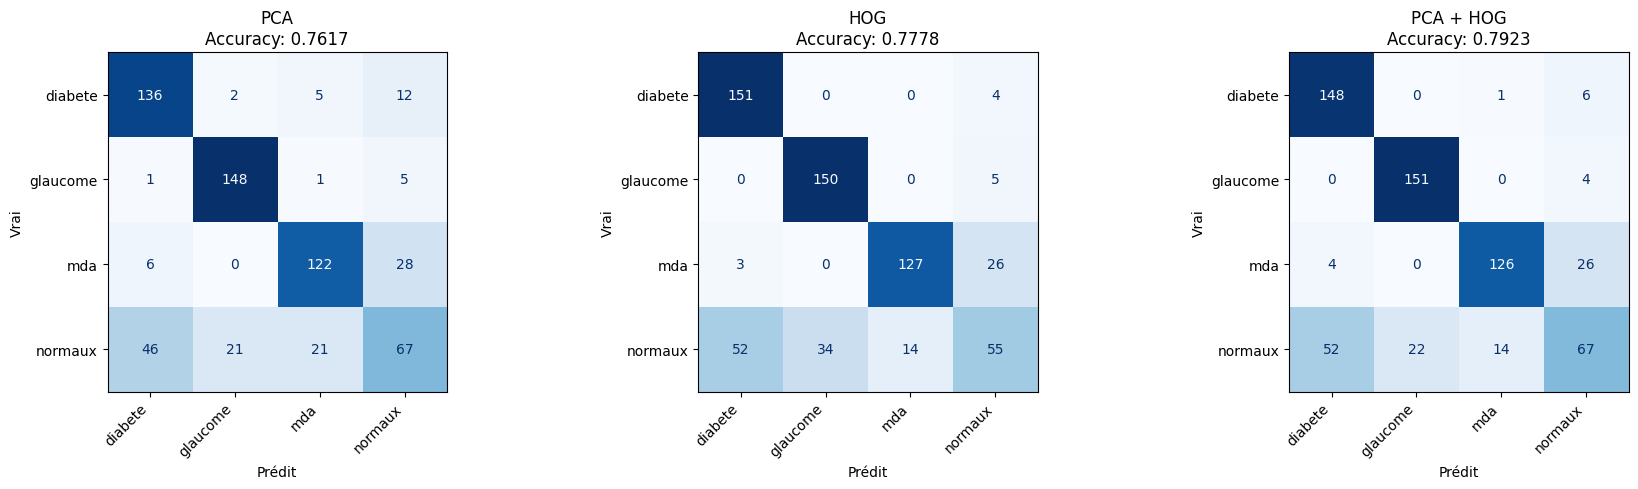

In [14]:
# Matrices de confusion pour chaque approche
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [15]:
# Rapport de classification détaillé pour la meilleure approche
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: {best_approach}")
print("="*70)

best_data = results[best_approach]
print(f"\nMeilleurs paramètres trouvés:")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification:")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: PCA + HOG

Meilleurs paramètres trouvés:
  xgb__subsample: 1.0
  xgb__reg_lambda: 2.0
  xgb__reg_alpha: 0
  xgb__n_estimators: 200
  xgb__min_child_weight: 3
  xgb__max_depth: 7
  xgb__learning_rate: 0.2
  xgb__gamma: 0
  xgb__colsample_bytree: 0.85
  features__pca__n_components: 30

Rapport de classification:
              precision    recall  f1-score   support

     diabete       0.73      0.95      0.82       155
    glaucome       0.87      0.97      0.92       155
         mda       0.89      0.81      0.85       156
     normaux       0.65      0.43      0.52       155

    accuracy                           0.79       621
   macro avg       0.79      0.79      0.78       621
weighted avg       0.79      0.79      0.78       621



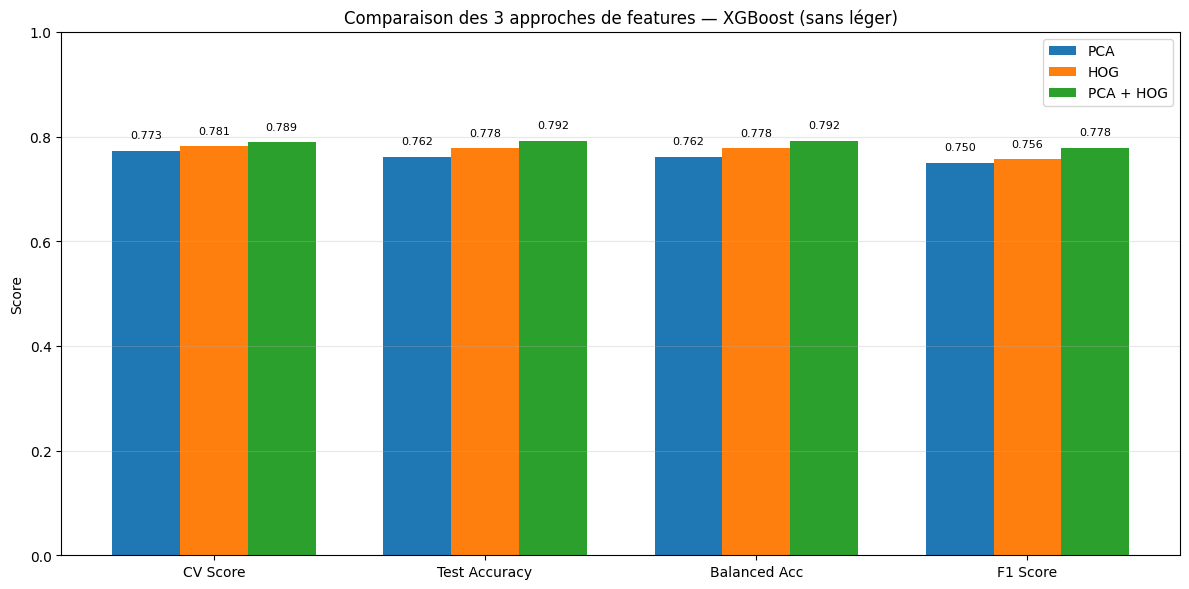

In [16]:
# Graphique comparatif des performances
metrics = ['CV Score', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['CV Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i*width, values, width, label=approach)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features — XGBoost (sans léger)')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['CV Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    for j, v in enumerate(values):
        ax.text(x[j] + i*width, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()